<a href="https://colab.research.google.com/github/Hiero-o/cp_01_tritiack/blob/main/Desafio_Final_Energia_ONS_API_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Desafio Final — Análise de Dados de Energia com API Pública

**Curso:** Ciência da Computação  
**Disciplina:** Soluções em Energias Renováveis e Sustentáveis

## Situação-problema

Uma equipe de planejamento energético precisa analisar o comportamento da carga elétrica de uma região atendida pelo Sistema Interligado Nacional (SIN).

Os dados serão obtidos diretamente de uma API pública do **Operador Nacional do Sistema Elétrico (ONS)**. A conexão com a API e a preparação inicial do JSON já estão fornecidas. A partir daí, sua equipe deverá construir o DataFrame, organizar os dados, criar recortes, calcular indicadores, produzir gráficos e elaborar um relatório técnico.

> Todos os códigos, resultados, gráficos e respostas devem permanecer neste mesmo Notebook.

## 1. Fonte dos dados

API pública de **Carga Verificada do ONS**:

- Portal: https://dados.ons.org.br/
- Conjunto de dados: https://dados.ons.org.br/dataset/carga-energia-verificada

Neste notebook será utilizada inicialmente a área **SP — São Paulo**, no período de **01/08/2025 a 07/09/2025**.

## 2. Bibliotecas

In [88]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

## 3. Consulta à API

Esta célula está pronta. Não é necessário conhecer `requests` para realizar o desafio.

In [89]:
url = "https://apicarga.ons.org.br/prd/cargaverificada"

parametros = {
    "dat_inicio": "2025-08-01",
    "dat_fim": "2025-09-07",
    "cod_areacarga": "SP"
}

response = requests.get(url, params=parametros, timeout=30)

print("Status:", response.status_code)
print("URL:", response.url)

response.raise_for_status()
dados_json = response.json()

Status: 200
URL: https://apicarga.ons.org.br/prd/cargaverificada?dat_inicio=2025-08-01&dat_fim=2025-09-07&cod_areacarga=SP


## 4. Preparação inicial do JSON

A célula abaixo localiza a lista principal de registros retornada pela API e a armazena em `registros`.

In [90]:
if isinstance(dados_json, list):
    registros = dados_json

elif isinstance(dados_json, dict):
    chaves_com_lista = [
        chave for chave, valor in dados_json.items()
        if isinstance(valor, list)
    ]

    if not chaves_com_lista:
        raise ValueError("A resposta não contém uma lista de registros.")

    chave_registros = chaves_com_lista[0]
    registros = dados_json[chave_registros]
    print("Chave utilizada:", chave_registros)

else:
    raise TypeError("Formato de JSON não reconhecido.")

print("Tipo:", type(registros))
print("Quantidade de registros:", len(registros))

if registros:
    print("\nPrimeiro registro:")
    print(registros[0])

Tipo: <class 'list'>
Quantidade de registros: 1824

Primeiro registro:
{'cod_areacarga': 'SP', 'din_atualizacao': '2026-08-14T05:58:29.574Z', 'dat_referencia': '2025-08-01', 'din_referenciautc': '2025-08-01T03:30:00.000Z', 'val_cargaglobal': 15913.618, 'val_cargaglobalcons': 15913.618, 'val_cargaglobalsmmgd': 15892.488, 'val_cargasupervisionada': 14421.112, 'val_carganaosupervisionada': 1471.3759, 'val_cargammgd': 21.13, 'val_consistencia': 0}


In [91]:
type(registros)

list

In [92]:
registros

[{'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T03:30:00.000Z',
  'val_cargaglobal': 15913.618,
  'val_cargaglobalcons': 15913.618,
  'val_cargaglobalsmmgd': 15892.488,
  'val_cargasupervisionada': 14421.112,
  'val_carganaosupervisionada': 1471.3759,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:00:00.000Z',
  'val_cargaglobal': 15251.414,
  'val_cargaglobalcons': 15251.414,
  'val_cargaglobalsmmgd': 15230.284,
  'val_cargasupervisionada': 13758.101,
  'val_carganaosupervisionada': 1472.184,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:30:00.000Z',
  'val_cargaglobal': 14606.733,
  'val_carga

# A partir daqui, o trabalho é da equipe

## DESAFIO 1 — Construção e inspeção do DataFrame

1. Crie um DataFrame Pandas chamado `dados` a partir de `registros`.
2. Exiba os primeiros registros.
3. Determine a quantidade de linhas e colunas.
4. Liste os nomes dos atributos.
5. Utilize `info()`.
6. Utilize `describe()`.
7. Em Markdown, identifique quais atributos representam data/hora, área de carga e valor de carga.

**Antes de prosseguir, compreenda a estrutura efetivamente retornada pela API.**

# DESAFIO 1 (Erick Banhos de Castro - RM 572131)

In [93]:
### Identificação dos atributos - Data/hora: `dat_referencia` - Área de carga: `cod_areacarga` - Valor de carga: `val_cargaglobal`

#1.
dados = pd.DataFrame(registros)
#2.
dados.head()
#3.
print("Quantidade de linhas:", dados.shape[0])
print("Quantidade de colunas:", dados.shape[1])
#4.
dados.columns.tolist()
#5.
dados.info()
#6.
dados.describe()

Quantidade de linhas: 1824
Quantidade de colunas: 11
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1824 entries, 0 to 1823
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cod_areacarga               1824 non-null   object 
 1   din_atualizacao             1824 non-null   object 
 2   dat_referencia              1824 non-null   object 
 3   din_referenciautc           1824 non-null   object 
 4   val_cargaglobal             1824 non-null   float64
 5   val_cargaglobalcons         1824 non-null   float64
 6   val_cargaglobalsmmgd        1824 non-null   float64
 7   val_cargasupervisionada     1824 non-null   float64
 8   val_carganaosupervisionada  1824 non-null   float64
 9   val_cargammgd               1824 non-null   float64
 10  val_consistencia            1824 non-null   int64  
dtypes: float64(6), int64(1), object(4)
memory usage: 156.9+ KB


,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
count,1824.000000,1824.000000,1824.000000,1824.000000,1824.000000,1824.000000,1824.0
mean,17976.306907,17976.306907,16926.075477,15497.620028,1428.455444,1050.231336,0.0
std,3135.183532,3135.183532,2979.280241,2990.596894,42.375101,1390.301396,0.0
min,11553.173000,11553.173000,10948.252000,9595.402000,1344.187300,21.080000,0.0
25%,15151.697500,15151.697500,14536.408500,13099.069750,1397.978825,21.130000,0.0
50%,18197.469000,18197.469000,16972.291000,15555.585500,1432.464200,23.102150,0.0
75%,20698.093000,20698.093000,18846.428500,17420.828500,1457.408700,2194.052000,0.0
max,24003.426000,24003.426000,23982.295000,22592.380000,1538.274700,4409.264000,0.0


## DESAFIO 2 — Organização dos dados

1. Renomeie os principais atributos com nomes mais simples.
2. Crie um novo DataFrame contendo apenas os atributos necessários.
3. Verifique valores ausentes.
4. Caso existam, informe quantos há em cada atributo relevante.
5. Verifique se a variável de carga está em formato numérico.
6. Verifique como a data/hora está representada.
7. Registre em Markdown qualquer decisão de tratamento.

In [94]:
df1 = dados.rename(columns={'din_referenciautc': 'data/hora',
                      'cod_areacarga': 'area_de_carga',
                      'val_cargaglobal': 'valor_de_carga'
                    }, inplace=True)

df1 = dados[['data/hora', 'area_de_carga', 'valor_de_carga']]


print(df1.isna().sum())

print(df1['valor_de_carga'].dtype)

print(df1['data/hora'].dtype)

df1.head()



data/hora         0
area_de_carga     0
valor_de_carga    0
dtype: int64
float64
object


,data/hora,area_de_carga,valor_de_carga
0,2025-08-01T03:30:00.000Z,SP,15913.618
1,2025-08-01T04:00:00.000Z,SP,15251.414
2,2025-08-01T04:30:00.000Z,SP,14606.733
3,2025-08-01T05:00:00.000Z,SP,14182.290
4,2025-08-01T05:30:00.000Z,SP,13838.488


### Desafio 2 — decisões de tratamento (Victor Henrique - 570021)

- Renomeei as colunas pra nomes mais simples: `data/hora`, `area_de_carga`, `valor_de_carga`.
- Fiquei só com essas 3 colunas, o resto não interessa pra essa análise.
- Sem valores ausentes (conferido com `isna().sum()`).
- `valor_de_carga` já vem numérico (`float64`), não precisou converter.
- `data/hora` vem como string (formato tipo `2025-08-01T03:30:00.000Z`), tipo `object`. Não converti agora, mas vou precisar usar `pd.to_datetime()` depois pra mexer com datas de verdade.

## DESAFIO 3 — Indicadores da carga elétrica

Calcule:

1. carga mínima;
2. carga máxima;
3. carga média;
4. mediana;
5. amplitude entre máximo e mínimo;
6. quantidade total de medições.

Depois responda:

**O valor máximo está muito distante do comportamento médio observado? Justifique com os indicadores calculados.**

In [95]:
menor_carga = df1['valor_de_carga'].min()

print(f"Menor Carga: {menor_carga:}")

maior_carga = df1['valor_de_carga'].max()

print(f"\nMaior Carga: {maior_carga}")

media_carga = df1['valor_de_carga'].mean()

print(f"\nMedia das Cargas: {media_carga:.2f}")

mediana_carga = df1['valor_de_carga'].median()

print(f"\nMediana das Cargas: {mediana_carga:.2f}")

amplitude_carga = maior_carga - menor_carga

print(f"\nAmplitude da Carga: {amplitude_carga:.2f}")

quantidade_registros = len(df1)

print(f"\nQuantidae de registros: {quantidade_registros}")

Menor Carga: 11553.173

Maior Carga: 24003.426

Media das Cargas: 17976.31

Mediana das Cargas: 18197.47

Amplitude da Carga: 12450.25

Quantidae de registros: 1824


### Desafio 3 — indicadores da carga elétrica (Gustavo RM 574156)

- Carga mínima: `11553.17`
- Carga máxima: `24003.42`
- Carga média: `17976.30`
- Mediana: `18197.46`
- Amplitude (máx - mín): `12450.25`
- Total de medições: `1824`

**O valor máximo está muito distante do comportamento médio?**

Não muito. A média (17976.30) e a mediana (18197.46) tão bem próximas uma da outra, o que já mostra que os dados não têm uma distorção forte. O máximo (24003.42) fica um pouco mais de 6000 acima da média, o que é quase metade da amplitude total (12450.25) — ou seja, é um valor alto, mas dentro da faixa de variação normal da série, não parece um pico isolado ou outlier.

## DESAFIO 4 — Períodos de alta demanda

Considere como **alta demanda** os registros com carga superior a **90% da carga máxima**.

1. Calcule o limiar.
2. Crie um novo DataFrame com os registros acima dele.
3. Conte os registros.
4. Calcule o percentual em relação ao total.
5. Identifique o maior valor de carga.
6. Identifique a data e o horário do pico, quando disponíveis.

Responda:

**Os períodos próximos ao pico representam uma parcela grande ou pequena do período analisado?**

In [96]:
carga_maxima = df1['valor_de_carga'].max()

limiar = carga_maxima * 0.90

print("Carga máxima:", carga_maxima)
print("Limiar de alta demanda (90%):", limiar)

df_alta_demanda = df1[df1['valor_de_carga'] > limiar].copy()

print("\nRegistros de alta demanda:")
display(df_alta_demanda)

quantidade_alta_demanda = len(df_alta_demanda)

print("\nQuantidade de registros acima do limiar:", quantidade_alta_demanda)

total_registros = len(df1)

percentual_alta_demanda = (quantidade_alta_demanda / total_registros) * 100

print("Percentual de registros de alta demanda:", round(percentual_alta_demanda, 2), "%")

maior_carga = df1['valor_de_carga'].max()

print("\nMaior valor de carga:", maior_carga)

indice_pico = df1['valor_de_carga'].idxmax()

data_pico = df1.loc[indice_pico, 'data/hora']
area_pico = df1.loc[indice_pico, 'area_de_carga']

print("Data e horário do pico:", data_pico)

print("Área de carga no pico:", area_pico)

Carga máxima: 24003.426
Limiar de alta demanda (90%): 21603.0834

Registros de alta demanda:


,data/hora,area_de_carga,valor_de_carga
36,2025-08-01T21:30:00.000Z,SP,22398.360
37,2025-08-01T22:00:00.000Z,SP,23185.312
38,2025-08-01T22:30:00.000Z,SP,22903.314
39,2025-08-01T23:00:00.000Z,SP,22358.701
40,2025-08-01T23:30:00.000Z,SP,21697.979
...,...,...,...
1716,2025-09-05T21:30:00.000Z,SP,22260.879
1717,2025-09-05T22:00:00.000Z,SP,22886.418
1718,2025-09-05T22:30:00.000Z,SP,22612.824
1719,2025-09-05T23:00:00.000Z,SP,22149.365



Quantidade de registros acima do limiar: 255
Percentual de registros de alta demanda: 13.98 %

Maior valor de carga: 24003.426
Data e horário do pico: 2025-08-21T22:00:00.000Z
Área de carga no pico: SP


# DESAFIO 4 (CARLOS RM 573334)

# DESAFIO 4

Calcular o limiar: 20866.7808 W

Crie um novo DataFrame com os registros acima dele.

Conte os registros: 50 (alta demanda) 336 (Total)

Calcule o percentual em relação ao total: 14.88%

Identifique o maior valor de carga: 23185.312 W

Identifique a data e o horário do pico, quando disponíveis:

Data e horário do pico: 2025-08-21T22:00:00.000Z

Os períodos próximos ao pico representam uma parcela grande ou pequena do período analisado?

Os períodos próximos ao pico representam uma parcela pequena do período analisado. Como a alta demanda foi definida como cargas acima de 90% do valor máximo, apenas uma parte dos registros se enquadra nesse critério. Dos 336 registros analisados, 50 apresentaram valores acima do limiar, correspondendo a 14,88% do total. Ou seja, os valores próximos ao pico aparecem em poucos momentos da série, enquanto a maior parte do período apresenta cargas abaixo desse nível.

## DESAFIO 5 — Segundo critério de análise

Crie um segundo recorte dos dados utilizando um critério definido pela equipe.

Possibilidades:

- carga acima da média;
- carga abaixo de uma porcentagem do máximo;
- intervalo de valores;
- determinado dia ou período;
- combinação de duas condições.

Apresente:

1. o critério escolhido;
2. o novo DataFrame;
3. a quantidade de registros;
4. o percentual;
5. a comparação com o conjunto de alta demanda.

## Desafio 5 — Erick Yu Xiang(RM569305)

O critério escolhido foi considerar os registros com **carga acima da média**.

A média da carga no período analisado foi de aproximadamente **17976,30 W**. Foi criado um novo DataFrame contendo somente os registros com `valor_de_carga` superior a esse valor.

Após o filtro, foi calculada a quantidade de registros e o percentual que eles representam em relação às **1824 medições totais**.

Comparando esse conjunto com o de **alta demanda**, que considera apenas valores superiores a 90% da carga máxima, o critério de carga acima da média é menos restritivo. Por isso, ele tende a selecionar uma quantidade maior de registros.

O recorte de alta demanda representa situações mais próximas do pico de consumo, enquanto o recorte acima da média permite observar de forma mais ampla os períodos em que a carga esteve acima do comportamento médio observado.


In [97]:
media_carga = df1['valor_de_carga'].mean()

df_acima_media = df1[
    df1['valor_de_carga'] > media_carga
].copy()

quantidade_acima_media = len(df_acima_media)

percentual_acima_media = (
    quantidade_acima_media / len(df1)
) * 100


quantidade_alta_demanda = len(df_alta_demanda)

percentual_alta_demanda = (
    quantidade_alta_demanda / len(df1)
) * 100

print("Média da carga:", round(media_carga, 2), "W")

print("\nRegistros com carga acima da média:")
display(df_acima_media)

print("\nQuantidade de registros:", quantidade_acima_media)
print("Percentual:", round(percentual_acima_media, 2), "%")

print("\nComparação com a alta demanda:")
print("Acima da média:", quantidade_acima_media,
      "registros -", round(percentual_acima_media, 2), "%")

print("Alta demanda (> 90% do máximo):",
      quantidade_alta_demanda,
      "registros -", round(percentual_alta_demanda, 2), "%")


Média da carga: 17976.31 W

Registros com carga acima da média:


,data/hora,area_de_carga,valor_de_carga
15,2025-08-01T11:00:00.000Z,SP,18096.023
16,2025-08-01T11:30:00.000Z,SP,18629.395
17,2025-08-01T12:00:00.000Z,SP,18825.176
18,2025-08-01T12:30:00.000Z,SP,19056.504
19,2025-08-01T13:00:00.000Z,SP,19427.822
...,...,...,...
1812,2025-09-07T21:30:00.000Z,SP,18262.123
1813,2025-09-07T22:00:00.000Z,SP,18716.031
1814,2025-09-07T22:30:00.000Z,SP,18574.328
1815,2025-09-07T23:00:00.000Z,SP,18422.092



Quantidade de registros: 950
Percentual: 52.08 %

Comparação com a alta demanda:
Acima da média: 950 registros - 52.08 %
Alta demanda (> 90% do máximo): 255 registros - 13.98 %


## DESAFIO 6 — Visualização

Construa **pelo menos dois gráficos**.

- Um deve representar o comportamento da carga ao longo das observações ou do tempo.
- O segundo deve ser escolhido pela equipe.

Inclua título, eixos e unidades quando aplicável.

Após cada gráfico, escreva uma interpretação curta.

## DESAFIO 6 - Júlia Lemos Souza (RM569089)

### Gráfico 1 — Comportamento da carga ao longo do tempo

/tmp/ipykernel_3667/1257003191.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['data/hora'] = pd.to_datetime(df1['data/hora'])


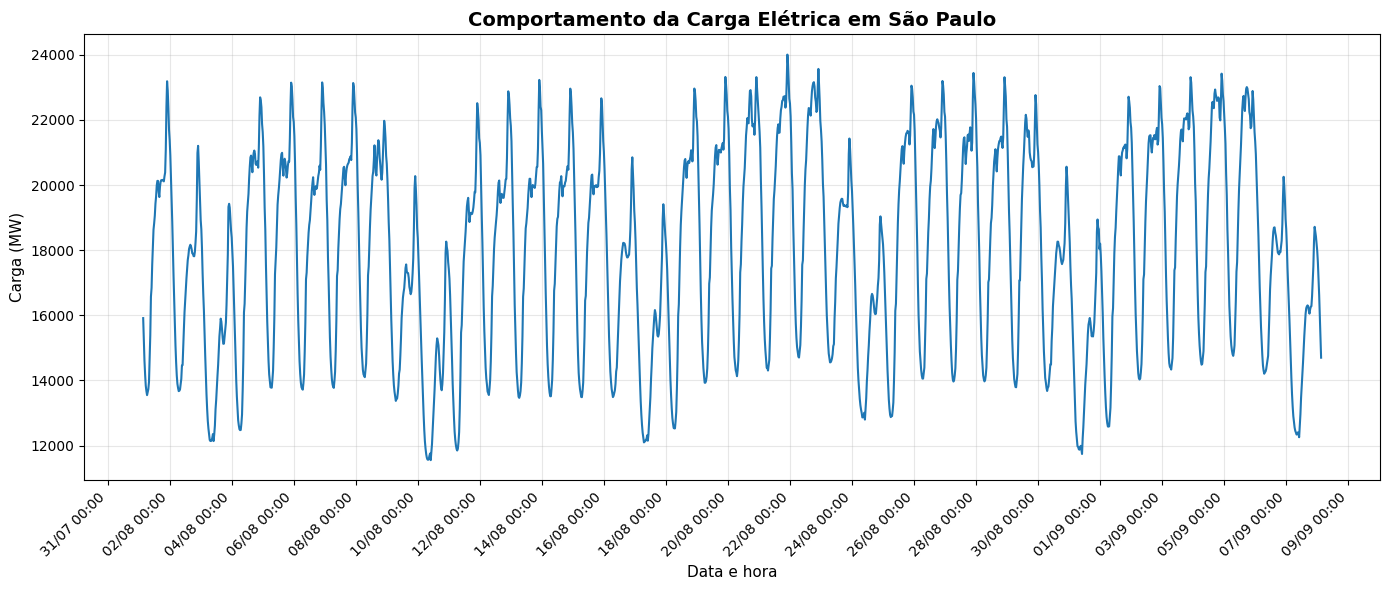

In [98]:
df1['data/hora'] = pd.to_datetime(df1['data/hora'])

plt.figure(figsize=(14, 6))

plt.plot(df1['data/hora'], df1['valor_de_carga'], linewidth=1.5)

plt.title('Comportamento da Carga Elétrica em São Paulo', fontsize=14, fontweight='bold')

plt.xlabel('Data e hora', fontsize=11)
plt.ylabel('Carga (MW)', fontsize=11)

# Setando os intevalos a cada dois dias.

plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))

# Formato das datas
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d/%m %H:%M'))

plt.xticks(rotation=45, ha='right')

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

O gráfico mostra como a carga elétrica variou ao longo do período analisado. É possível observar que a carga não permanece constante, apresentando momentos de aumento e redução. Os maiores valores aparecem principalmente nos períodos de maior demanda, enquanto em outros horários a carga apresenta valores menores.

### Gráfico 2 - Comparação entre carga máxima e carga média

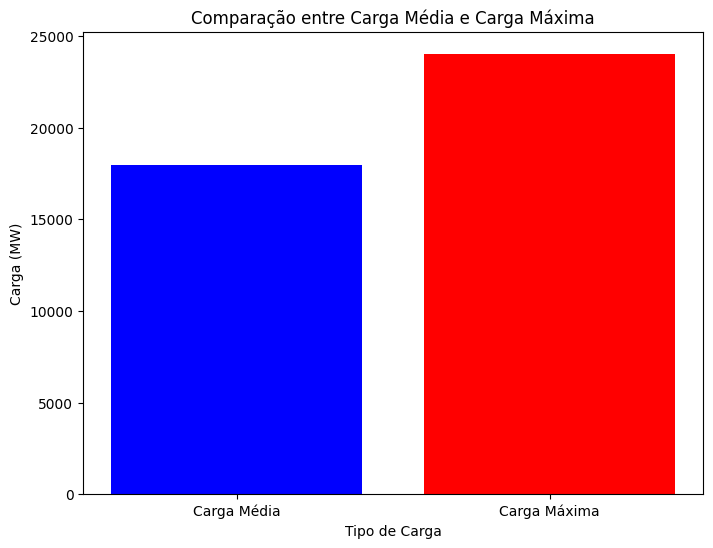

In [99]:
carga_maxima = df1['valor_de_carga'].max()
carga_media = df1['valor_de_carga'].mean()

valores = [carga_media, carga_maxima]
nomes = ['Carga Média', 'Carga Máxima']

plt.figure(figsize=(8, 6))
plt.bar(nomes, valores, color=['blue', 'red'])

plt.title('Comparação entre Carga Média e Carga Máxima')
plt.xlabel('Tipo de Carga')
plt.ylabel('Carga (MW)')

plt.show()

O segundo gráfico compara a carga média registrada durante o período com a maior carga registrada. A carga máxima é maior que a média, mostrando que existiram momentos de demanda elevada durante o período analisado. Essa comparação ajuda a visualizar a diferença entre o comportamento médio da carga e o momento de maior demanda.

## DESAFIO 7 — Síntese para o relatório

Crie uma variável `resumo_resultados` contendo pelo menos:

- região;
- período;
- quantidade de registros;
- carga mínima;
- carga máxima;
- carga média;
- mediana;
- limiar de alta demanda;
- quantidade e percentual de alta demanda;
- momento do pico;
- resultado do segundo critério.

A IA deverá receber **resultados produzidos por vocês**, e não substituir a análise.

In [100]:
resumo_resultados=f"""
  Região analisada: São Paulo, SP
  Período analisado: 01/08/2025 até 07/09/2025
  Quantidade de registros: 1824
  Carga mínima: {menor_carga}
  Carga máxima: {maior_carga}
  Carga média: {media_carga:.2f}
  Mediana: {mediana_carga:.2f}
  Limiar de alta demanda: {limiar:.2f}
  Registros de alta demanda: {quantidade_alta_demanda}
  Percentual de alta demanda: {percentual_alta_demanda:.2f}%
  Momento do pico: {data_pico}
  Segundo critério:
  Acima da média: {quantidade_acima_media} registros - {percentual_acima_media:.2f}%
"""

print("Relatório antes da revisão")

print(resumo_resultados)

relatorio = f"""
Durante o período analisado, de 01/08/2025 até 07/09/2025, a região analisada foi São Paulo (SP),
Com 1824 registros, uma gama sólida de dados foi coletada. A diferença entre mediana e média é ligeiramente superior
para a mediana indicando maiores casos de alta demanda acima da metade entre carga mínima e máxima.

Com o limiar de alta demanda estando em {percentual_alta_demanda:.2f}%, com um total de  255 registros, ou seja, {percentual_alta_demanda:.2f}%.

Com cerca de {round(percentual_acima_media)}% de registros acima da média, ou, {quantidade_acima_media}. Indicam o uso rotineiro de energia elétrica na região de São Paulo observada.

Enquanto {quantidade_alta_demanda}, representam os valores extremos de consumo de energia no período.

E cerca de {round(100 - percentual_acima_media)}% foram registros abaixo da média.

Os registros de carga em São Paulo, no período analisado, apresentaram resultados médios de {media_carga:.2f},
se mantendo acima desse valor em cerca de {round(percentual_acima_media)}%, Os outliers, representam cerca de {round(limiar)}% dos registros,
sendo o ponto máximo, no momento: {data_pico}.
"""

print(relatorio)

Relatório antes da revisão

  Região analisada: São Paulo, SP
  Período analisado: 01/08/2025 até 07/09/2025
  Quantidade de registros: 1824
  Carga mínima: 11553.173
  Carga máxima: 24003.426
  Carga média: 17976.31
  Mediana: 18197.47
  Limiar de alta demanda: 21603.08
  Registros de alta demanda: 255
  Percentual de alta demanda: 13.98%
  Momento do pico: 2025-08-21T22:00:00.000Z
  Segundo critério:
  Acima da média: 950 registros - 52.08%


Durante o período analisado, de 01/08/2025 até 07/09/2025, a região analisada foi São Paulo (SP),
Com 1824 registros, uma gama sólida de dados foi coletada. A diferença entre mediana e média é ligeiramente superior
para a mediana indicando maiores casos de alta demanda acima da metade entre carga mínima e máxima.

Com o limiar de alta demanda estando em 13.98%, com um total de  255 registros, ou seja, 13.98%.

Com cerca de 52% de registros acima da média, ou, 950. Indicam o uso rotineiro de energia elétrica na região de São Paulo observada.

Enq

# OPCIONAL: Relatório técnico com apoio do Gemini

No Colab:

1. abra **Secrets**;
2. crie `GEMINI_API_KEY`;
3. informe sua chave;
4. permita o acesso do notebook ao secret.

**Não coloque a chave diretamente no código.**

In [101]:
!pip -q install -U google-genai

In [102]:
from google.colab import userdata
from google import genai

GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")
client = genai.Client(api_key=GEMINI_API_KEY)

## DESAFIO 8 — Geração do relatório

O relatório deve:

- usar os resultados calculados;
- apresentar os principais indicadores;
- destacar o pico e os períodos de alta demanda;
- comparar os dois critérios;
- não inventar causas;
- diferenciar observações de hipóteses;
- terminar com uma conclusão.

In [103]:
prompt = f'''
Atue como analista de dados do setor elétrico.

Produza um relatório técnico curto com base EXCLUSIVAMENTE nos resultados abaixo.

Não invente causas para as variações observadas.
Não apresente como fato explicações que não possam ser sustentadas pelos dados.
Diferencie claramente resultados observados de hipóteses.

Inclua:
1. caracterização do conjunto analisado;
2. principais indicadores;
3. análise dos períodos de alta demanda;
4. comparação com o segundo critério;
5. conclusão.

RESULTADOS DA EQUIPE:

{resumo_resultados}
'''

In [104]:
response_gemini = client.models.generate_content(
    model="gemini-3.6-flash",
    contents=prompt
)

print(response_gemini.text)

**RELATÓRIO TÉCNICO DE ANÁLISE DE CARGA ELÉTRICA**

**Localidade:** São Paulo, SP  
**Período de Análise:** 01/08/2025 a 07/09/2025  
**Elaborado por:** Analista de Dados do Setor Elétrico  

---

### 1. Caracterização do Conjunto Analisado
O presente relatório analisa o comportamento da demanda de carga elétrica na região de São Paulo, SP, cobrindo o período de 01 de agosto de 2025 a 07 de setembro de 2025. O conjunto de dados consolidado possui um volume total de **1.824 registros** de amostragem.

---

### 2. Principais Indicadores
Com base nos dados coletados durante o período, foram apurados os seguintes indicadores do perfil de carga:

* **Carga Mínima:** 11.553,173
* **Carga Máxima (Pico):** 24.003,426
* **Carga Média:** 17.976,31
* **Mediana:** 18.197,47

**Resultado Observado:** A mediana do conjunto (18.197,47) apresenta-se ligeiramente superior à média (17.976,31), indicando uma distribuição com leve concentração de valores no segmento superior da curva.

---

### 3. Análise

## DESAFIO 9 — Validação crítica

Compare o texto gerado pelo Gemini com os cálculos, DataFrames e gráficos.

Responda:

1. Os indicadores foram utilizados corretamente?
2. Há alguma afirmação que não pode ser confirmada pelos dados?
3. Houve interpretação exagerada ou causalidade não demonstrada?
4. Que alterações a equipe realizou no texto?

## Relatório final

Insira abaixo a versão final revisada pela equipe.

# Revisão

### 1 - Sim, os indicadores foram utilizados de forma correta.

### 2 - Assim como o próprio modelo já disse, não há como confirmar as causas dos picos de uso de energia elétrica em certos períodos, apenas hipoteticamente.

### 3 - Não foram identificados interpretações exageradas. O modelo deixou claro que as possíveis causas dos picos não poderiam ser confirmadas com os dados disponíveis.

### 4 - Retiramos as hipóteses sugeridas pelo modelo e mantivemos apenas as informações que podem ser confirmadas com os dados disponíveis.

# RELATÓRIO TÉCNICO DE ANÁLISE DE CARGA ELÉTRICA

Localidade: São Paulo, SP
Período de Análise: 01/08/2025 a 07/09/2025
Elaborado por: Analista de Dados do Setor Elétrico

---

### 1. Caracterização do Conjunto Analisado

O presente relatório analisa o comportamento da demanda de carga elétrica na região de São Paulo, SP, cobrindo o período de 01 de agosto de 2025 a 07 de setembro de 2025. O conjunto de dados consolidado possui um volume total de **1.824 registros** de amostragem.

---

### 2. Principais Indicadores

Com base nos dados coletados durante o período, foram apurados os seguintes indicadores do perfil de carga:

* Carga Mínima: 11.553,173 W
* Carga Máxima (Pico): 24.003,426 W
* Carga Média: 17.976,31 W
* Mediana: 18.197,47 W

**Resultado Observado:** A mediana do conjunto (18.197,47 W) apresenta-se ligeiramente superior à média (17.976,31 W), indicando que os valores centrais da distribuição estão próximos, com a mediana posicionada acima do valor médio calculado.

---

### 3. Análise dos Períodos de Alta Demanda

Para a identificação dos eventos de maior demanda, estabeleceu-se um limiar operacional correspondente a 90% da carga máxima:

* Limiar de Alta Demanda: 21.603,08 W
* Registros em Alta Demanda: 255
* Representatividade: 13,98% do total de registros
* Pico Máximo Registrado: 2025-08-21T22:00:00.000Z (Carga: 24.003,426 W)

Resultados Observados: Os registros classificados como alta demanda representam 13,98% do total de registros analisados. O ponto máximo absoluto de carga do período ocorreu no dia 21/08/2025, às 22:00 UTC.

**Diferenciação entre Fatos e Hipóteses:**

* Fato Observado: O pico máximo atingiu 24.003,426 W no horário indicado.

---

### 4. Comparação com o Segundo Critério

A avaliação da carga foi submetida a dois critérios de segmentação distintos:

1. Critério 1 (Alta Demanda / Limiar de 21.603,08 W): 255 registros (13,98% do total).
2. Critério 2 (Registros Acima da Média / Limiar > 17.976,31 W): 950 registros (52,08% do total).

Resultado Observado: O segundo critério revela que 52,08% dos registros analisados apresentaram carga acima da média geral. O critério de alta demanda, por ser mais restritivo, isola apenas os 255 registros que apresentaram valores superiores a 90% da carga máxima.

---

### 5. Conclusão

* A demanda na região de São Paulo, SP, durante o período analisado, oscilou entre a mínima de 11.553,173 W e a máxima de 24.003,426 W.
* 52,08% dos registros apresentaram valores de carga acima da média amostral de 17.976,31 W.
* As situações de maior exigência (alta demanda) representaram 13,98% do total de registros, culminando no evento de pico do dia 21/08/2025 às 22:00:00.000Z.
* Recomenda-se a inclusão de variáveis meteorológicas e operacionais em análises futuras para possibilitar a investigação de possíveis fatores associados aos momentos de maior demanda.


---

## Entrega

O notebook deve apresentar:

- consulta à API executada;
- DataFrame criado;
- inspeção e organização dos dados;
- indicadores;
- pelo menos dois DataFrames derivados por critérios;
- percentuais;
- pelo menos dois gráficos;
- interpretações;
- síntese para a IA;
- relatório com apoio do Gemini;
- validação crítica;
- versão final revisada.

**Entregue somente este Notebook (.ipynb), com todas as células executadas e os resultados visíveis.**